In [2]:
print("hello")

hello


In [3]:
import numpy as np
import time

In [4]:
pulsedmasterlogic.module_state()

'idle'

In [ ]:
pulsedmasterlogic.elapsed_sweeps

In [3]:
pulsedmasterlogic.set_generation_parameters(microwave_channel='d_ch2',sync_channel= '', microwave_amplitude=0, rabi_period=300e-9)

In [4]:
for param, value in pulsedmasterlogic.generation_parameters.items():
    print('{0}: {1}'.format(param, value))

laser_channel: d_ch4
sync_channel: 
gate_channel: d_ch1
microwave_channel: d_ch2
microwave_frequency: 2870000000.0
microwave_amplitude: 0
rabi_period: 3e-07
laser_length: 1.5e-07
laser_delay: 8.5e-07
wait_time: 0.0001
analog_trigger_voltage: 0.0


In [5]:
type(pulsedmeasurementlogic)

<class 'logic.pulsed.pulsed_measurement_logic_CHANGED.PulsedMeasurementLogic'>

## Can I ACCESS Sampling settings from pulsed master???????

In [5]:
pulsedmasterlogic.generation_parameters['laser_length']

1.5e-07

In [6]:
pulsedmasterlogic.fast_counter_settings['record_length']

2000.0

In [3]:
print(pulsedmeasurementlogic.laser_data.dtype)
print(pulsedmeasurementlogic.data['Signal (counts)'].dtype)

Traceback (most recent call last):
  File "C:\Users\SingleNV\qudi_old\logic\jupyterkernel\qzmqkernel.py", line 679, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-3-34f05c09d817>", line 2, in <module>
    print(pulsedmeasurementlogic.data['Signal (counts)'].dtype)
AttributeError: 'PulsedMeasurementLogic' object has no attribute 'data'


float64


### Can I change a method from here?? 

In [6]:
import types

def fast_counter_pause_new(self):
    """Switching off the fast counter"""
    print("fast_counter_pause")
    print("Hello I'm Jupyter")
    return self.fastcounter().pause_measure()

pulsedmeasurementlogic.fast_counter_pause = types.MethodType(
    fast_counter_pause_new,
    pulsedmeasurementlogic
)

In [12]:
# If everything is properly set, we can start a measurement simply by calling:
pulsedmasterlogic.toggle_pulsed_measurement(True)
# Wait until the pulsedmeasurementlogic is actually busy and the measurement is running
while pulsedmeasurementlogic.module_state() != 'locked':
    time.sleep(0.2)

In [13]:
pulsedmasterlogic.toggle_pulsed_measurement(False)
# Wait until the pulsedmeasurementlogic is actually idle and the measurement is stopped
while pulsedmeasurementlogic.module_state() == 'locked':
    time.sleep(0.2)

### ofc I CAN!!

## Running Ordinary T1 from here

In [7]:
# This property contains all available predefined generate method names together with the respective set 
# of parameters with default values.
for method, params in pulsedmasterlogic.generate_method_params.items():
    print('{0}:\n  {1}'.format(method, params))

AEchirpedodmr:
  {'name': 'AllenEberlyChirpODMR', 'mw_freq_center': 2870000000.0, 'freq_range': 500000000.0, 'freq_overlap': 20000000.0, 'num_of_points': 50, 'pulse_length': 5e-07, 'truncation_ratio': 0.1, 'expected_rabi_frequency': 30000000.0, 'expected_t2': 5e-06, 'peak_mw_amplitude': 0.25}
HHamp:
  {'name': 'hh_amp', 'spinlock_length': 2e-05, 'amp_start': 0.05, 'amp_step': 0.01, 'num_of_points': 50}
HHpol:
  {'name': 'hh_pol', 'spinlock_length': 2e-05, 'spinlock_amp': 0.1, 'polarization_steps': 50}
HHtau:
  {'name': 'hh_tau', 'spinlock_amp': 0.1, 'tau_start': 1e-06, 'tau_step': 1e-06, 'num_of_points': 50}
chirpedodmr:
  {'name': 'LinearChirpedODMR', 'mw_freq_center': 2870000000.0, 'freq_range': 500000000.0, 'freq_overlap': 20000000.0, 'num_of_points': 50, 'pulse_length': 5e-07, 'expected_rabi_frequency': 30000000.0, 'expected_t2': 5e-06}
hahnecho:
  {'name': 'hahn_echo', 'tau_start': 0.0, 'tau_step': 1e-06, 'num_of_points': 50, 'alternating': True}
hahnecho_exp:
  {'name': 'hahn_ech

In [14]:
# Get the dictionary containing the default parameters for the desired sequence and alter the values as needed.
generate_params = pulsedmasterlogic.generate_method_params['t1_contrast']
generate_params['name'] = 'T1_contrast_based'
generate_params['tau_start'] =300e-09
generate_params['tau_step'] = 10e-06
generate_params['num_of_points'] = 100
generate_params['alternating'] = False

# Call the actual generation method using a wrapper method and pass the parameter set
pulsedmasterlogic.generate_predefined_sequence('t1_contrast', generate_params)
# Give it a moment to generate
time.sleep(0.5)

# The created object is a PulseBlockEnsemble instance, a recipe to create a waveform.
# You can get all created PulseBlockEnsembles using this property (keys are ensemble names, values are the object instances):
for ensemble_name in pulsedmasterlogic.saved_pulse_block_ensembles.keys():
    print(ensemble_name)

T1
T1_contrast_based
T1_exp
T1_exp_contrastbased
Testing_test
laser
pulsedODMR


In [15]:
# The "with_load" flag can be used to also load the waveform into the channels after creating it

pulsedmasterlogic.sample_ensemble('T1_contrast_based', with_load=True)

# Wait for the sampling to finish. There is a status dictionary that can be used to check for process status.

while pulsedmasterlogic.status_dict['sampload_busy']:

    time.sleep(0.1)

In [16]:
# You can check on the currently loaded asset on the pulse generator by using the following property:
print('currently loaded asset:', pulsedmasterlogic.loaded_asset)

# You can check on all created waveforms on the pulse generator by using the following property:
print('Available waveforms on device:', pulsedmasterlogic.sampled_waveforms)

currently loaded asset: ('T1_contrast', 'PulseBlockEnsemble')
Available waveforms on device: ['T1_contrast_based']


In [29]:
# If the pulse sequence has been generated not using predefined methods (e.g. using the graphical table editor) the 
# measurement settings have to be given manually.
# In the same way as setting the generation parameters you can either pass a settings dictionary or single keyword 
# arguments or a combination of both:
pulsedmasterlogic.set_measurement_settings(invoke_settings=False, 
                                           controlled_variable=30e-8 + np.arange(100) * 10e-06,
                                           number_of_lasers=100, 
                                           laser_ignore_list=[], 
                                           alternating=False, 
                                           units=('s', 'arb. u.'))
time.sleep(0.5)


In [37]:
# You can get a read-only view of the current measurement settings by using this property:
for setting, value in pulsedmasterlogic.measurement_settings.items():
    print('{0}:\n  {1}'.format(setting, value))

invoke_settings:
  False
controlled_variable:
  [3.000e-07 1.030e-05 2.030e-05 3.030e-05 4.030e-05 5.030e-05 6.030e-05
 7.030e-05 8.030e-05 9.030e-05 1.003e-04 1.103e-04 1.203e-04 1.303e-04
 1.403e-04 1.503e-04 1.603e-04 1.703e-04 1.803e-04 1.903e-04 2.003e-04
 2.103e-04 2.203e-04 2.303e-04 2.403e-04 2.503e-04 2.603e-04 2.703e-04
 2.803e-04 2.903e-04 3.003e-04 3.103e-04 3.203e-04 3.303e-04 3.403e-04
 3.503e-04 3.603e-04 3.703e-04 3.803e-04 3.903e-04 4.003e-04 4.103e-04
 4.203e-04 4.303e-04 4.403e-04 4.503e-04 4.603e-04 4.703e-04 4.803e-04
 4.903e-04 5.003e-04 5.103e-04 5.203e-04 5.303e-04 5.403e-04 5.503e-04
 5.603e-04 5.703e-04 5.803e-04 5.903e-04 6.003e-04 6.103e-04 6.203e-04
 6.303e-04 6.403e-04 6.503e-04 6.603e-04 6.703e-04 6.803e-04 6.903e-04
 7.003e-04 7.103e-04 7.203e-04 7.303e-04 7.403e-04 7.503e-04 7.603e-04
 7.703e-04 7.803e-04 7.903e-04 8.003e-04 8.103e-04 8.203e-04 8.303e-04
 8.403e-04 8.503e-04 8.603e-04 8.703e-04 8.803e-04 8.903e-04 9.003e-04
 9.103e-04 9.203e-04 9.303e-0

In [38]:
# In case you used "invoke_Settings" this part is not necessary
# The number_of_gates is only used in case of a hardware gated fast counter. It will always be set to 0 otherwise.
# The record length should be the length of the pulse sequence for an ungated counter and the length of the longest 
# gate for a gated counter.
pulsedmasterlogic.set_fast_counter_settings(record_length=5e3, number_of_gates=100)
time.sleep(0.5)

In [40]:
# You can see the current fast counter settings with the this property:
for setting, value in pulsedmasterlogic.fast_counter_settings.items():
    print('{0}: {1}'.format(setting, value))

bin_width: 1e-06
record_length: 5000.0
number_of_gates: 100
is_gated: True


Imma just start the measurement

In [41]:
# If everything is properly set, we can start a measurement simply by calling:
pulsedmasterlogic.toggle_pulsed_measurement(True)
# Wait until the pulsedmeasurementlogic is actually busy and the measurement is running
while pulsedmeasurementlogic.module_state() != 'locked':
    time.sleep(0.2)

In [42]:
pulsedmasterlogic.toggle_pulsed_measurement(False)
# Wait until the pulsedmeasurementlogic is actually idle and the measurement is stopped
while pulsedmeasurementlogic.module_state() == 'locked':
    time.sleep(0.2)

In [56]:
t_axis=pulsedmeasurementlogic.signal_data[0]

In [57]:
contrast = pulsedmeasurementlogic.signal_data[1]
error = pulsedmeasurementlogic.measurement_error[1]

In [58]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

In [59]:
def analyze(contrast, error, mtime):
    def exponential(x, a, b, c):
        return a * np.exp(-b * x) + c
    # Normalize data
    Y = contrast
    Y_std = error
    Y_normalized = Y #/ np.max(Y)
    Y_std_normalized = Y_std #/ np.max(Y)

    # Fit the data
    guess = [0.02, 0.8, 0.8]
    popt, pcov = curve_fit(exponential, mtime, Y_normalized, p0=guess, bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))
    T1 = 1 / popt[1]
    # Calculate R-squared
    residuals = Y_normalized - exponential(mtime, *popt)
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((Y_normalized - np.mean(Y_normalized)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    # Calculate standard error for T1
    perr = np.sqrt(np.diag(pcov))
    b_std = perr[1]
    T1_std = T1 * (b_std / popt[1])
    # Plot the data and the fit
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(mtime*1e3, Y_normalized, yerr=Y_std_normalized, fmt='o', color='black', label='Mean value')
    #ax.plot(mtime*1e3, Y_normalized, color='black', label='Mean value')
    ax.plot(mtime*1e3, exponential(mtime, *popt), '--', color='red',
            label=f'Fitted curve: T1 = {T1*1e3:.3f} +/- {T1_std*1e3:.3f} ms, $R^2$ = {r_squared:.3f}')
    #ax.set_xscale('log')  # Set x-axis to log scale
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Normalized Contrast')
    #ax.set_title('data/data_26/July/A549_Ctrl_TritonX S3/T1_14_fit')
    ax.legend()
    plt.tight_layout()
    # Save the plot
    #fit_image_name = "C:\Data\\2026\\07\\20260722\PulsedMeasurement\\T1_14_fit_" + date + ".png"
    #plt.savefig(fit_image_name)
    plt.show()

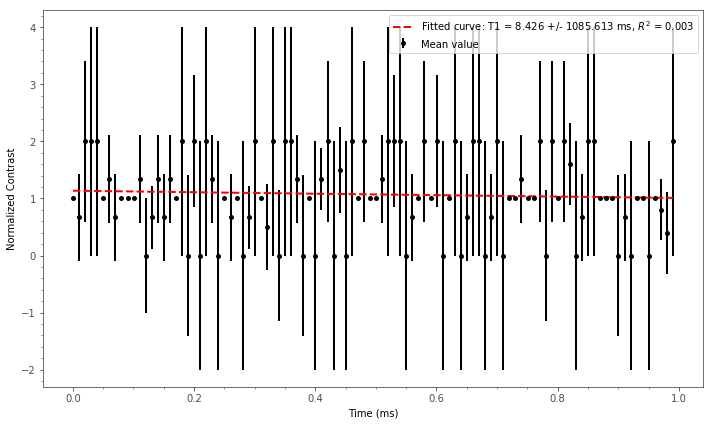

In [60]:
analyze(contrast, error, t_axis)

## Trying the NP t1

In [24]:
log_max = np.log10(3e-3)
log_min = np.log10(300e-9)
Ns = 25
t_axis = np.logspace(log_min, log_max, num=Ns, base=10.0, dtype=float)

In [25]:
print(t_axis)
sum(t_axis)

0.009412365746633507

[3.00000000e-07 4.40339780e-07 6.46330407e-07 9.48683298e-07
 1.39247665e-06 2.04387621e-06 3.00000000e-06 4.40339780e-06
 6.46330407e-06 9.48683298e-06 1.39247665e-05 2.04387621e-05
 3.00000000e-05 4.40339780e-05 6.46330407e-05 9.48683298e-05
 1.39247665e-04 2.04387621e-04 3.00000000e-04 4.40339780e-04
 6.46330407e-04 9.48683298e-04 1.39247665e-03 2.04387621e-03
 3.00000000e-03]


In [26]:
# If the pulse sequence has been generated not using predefined methods (e.g. using the graphical table editor) the 
# measurement settings have to be given manually.
# In the same way as setting the generation parameters you can either pass a settings dictionary or single keyword 
# arguments or a combination of both:
pulsedmasterlogic.set_measurement_settings(invoke_settings=False, 
                                           controlled_variable=[0],
                                           number_of_lasers=1, 
                                           laser_ignore_list=[], 
                                           alternating=False, 
                                           units=('s', 'arb. u.'))
time.sleep(0.5)

In [27]:
# In case you used "invoke_Settings" this part is not necessary
# The number_of_gates is only used in case of a hardware gated fast counter. It will always be set to 0 otherwise.
# The record length should be the length of the pulse sequence for an ungated counter and the length of the longest 
# gate for a gated counter.
pulsedmasterlogic.set_fast_counter_settings(record_length=2e3, number_of_gates=1)
time.sleep(0.5)

# You can see the current fast counter settings with the this property:
for setting, value in pulsedmasterlogic.fast_counter_settings.items():
    print('{0}: {1}'.format(setting, value))

bin_width: 5e-08
record_length: 2000.0
number_of_gates: 1
is_gated: True


In [28]:
Nr = 1
odmr_contrast = np.ones((Nr, Ns))
odmr_contrast_err = np.ones((Nr, Ns))
def sweep():
    for j in range(Nr):
        print("Run " + str(j + 1) + "   #####################################################################")
        for k in range(Ns):
            time.sleep(.005)
            uw_width = t_axis[k]

            # Get the dictionary containing the default parameters for the desired sequence and alter the values as needed.
            generate_params = pulsedmasterlogic.generate_method_params['t1_exponential_contrast']
            generate_params['name'] = 'T1_single'
            generate_params['tau_start'] = uw_width
            generate_params['tau_end'] = uw_width
            generate_params['num_of_points'] = 1
            generate_params['alternating'] = False

            # Call the actual generation method using a wrapper method and pass the parameter set
            pulsedmasterlogic.generate_predefined_sequence('t1_exponential_contrast', generate_params)
            # Give it a moment to generate
            time.sleep(0.005)
            # The "with_load" flag can be used to also load the waveform into the channels after creating it

            pulsedmasterlogic.sample_ensemble('T1_single', with_load=True)

            # Wait for the sampling to finish. There is a status dictionary that can be used to check for process status.

            while pulsedmasterlogic.status_dict['sampload_busy']:
                time.sleep(0.001)
            # You can check on the currently loaded asset on the pulse generator by using the following property:
            print('currently loaded asset:', pulsedmasterlogic.loaded_asset)

            # You can check on all created waveforms on the pulse generator by using the following property:
            print('Available waveforms on device:', pulsedmasterlogic.sampled_waveforms)
            
            ############################################################
            # If everything is properly set, we can start a measurement simply by calling:
            pulsedmasterlogic.toggle_pulsed_measurement(True) 
            print("initial state:", pulsedmeasurementlogic.module_state())
            poimanagerlogic.start_periodic_refocus()
            
            # Wait until the pulsedmeasurementlogic is actually busy and the measurement is running
            while pulsedmeasurementlogic.module_state() != 'locked':
                time.sleep(0.002)
            print("2")
            
            
            # If everything is properly set, we can stop a measurement simply by calling:
            pulsedmasterlogic.toggle_pulsed_measurement(False)
            # Wait until the pulsedmeasurementlogic is actually idle and the measurement is stopped
            while pulsedmeasurementlogic.module_state() == 'locked':
                #print(pulsedmeasurementlogic.module_state())
                time.sleep(0.2)

            print("Final state:", pulsedmeasurementlogic.module_state())
            poimanagerlogic.stop_periodic_refocus()
            ############################################################
            
            contrast = pulsedmeasurementlogic.signal_data[1]
            error = pulsedmeasurementlogic.measurement_error[1]
            odmr_contrast[j, k] = contrast[0]
            odmr_contrast_err[j, k] = error[0]
            print(str(uw_width) + " " + str(contrast) + " " + str(error))

In [29]:
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt

def analyze(contrast, error, mtime):
    def exponential(x, a, b, c):
        return a * np.exp(-b * x) + c
    # Normalize data
    Y = contrast
    Y_std = error
    Y_normalized = Y #/ np.max(Y)
    Y_std_normalized = Y_std #/ np.max(Y)
    
    # Fit the data
    guess = [0.02, 0.8, 0.8]
    popt, pcov = curve_fit(exponential, mtime, Y_normalized, p0=guess, bounds=([0, 0, 0], [np.inf, np.inf, np.inf]))
    T1 = 1 / popt[1]
    # Calculate R-squared
    residuals = Y_normalized - exponential(mtime, *popt)
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((Y_normalized - np.mean(Y_normalized)) ** 2)
    r_squared = 1 - (ss_res / ss_tot)
    # Calculate standard error for T1
    perr = np.sqrt(np.diag(pcov))
    b_std = perr[1]
    T1_std = T1 * (b_std / popt[1])
    # Plot the data and the fit
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(mtime*1e3, Y_normalized, yerr=Y_std_normalized, fmt='o', color='black', label='Mean value')
    #ax.plot(mtime*1e3, Y_normalized, color='black', label='Mean value')
    ax.plot(mtime*1e3, exponential(mtime, *popt), '--', color='red',
            label=f'Fitted curve: T1 = {T1*1e3:.3f} +/- {T1_std*1e3:.3f} ms, $R^2$ = {r_squared:.3f}')
    ax.set_xscale('log')  # Set x-axis to log scale
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Normalized Contrast')
    #ax.set_title('data/data_26/July/A549_Ctrl_TritonX S3/T1_14_fit')
    ax.legend()
    plt.tight_layout()
    # Save the plot
    #fit_image_name = "C:\Data\\2026\\07\\20260722\PulsedMeasurement\\T1_14_fit_" + date + ".png"
    #plt.savefig(fit_image_name)
    plt.show()

In [ ]:
Nr = 1
odmr_contrast = np.ones((Nr, Ns))
odmr_contrast_err = np.ones((Nr, Ns))
sweep()

Run 1   #####################################################################
currently loaded asset: ('T1_exp', 'PulseBlockEnsemble')
Available waveforms on device: ['T1_exp_contrastbased']
initial state: idle
2


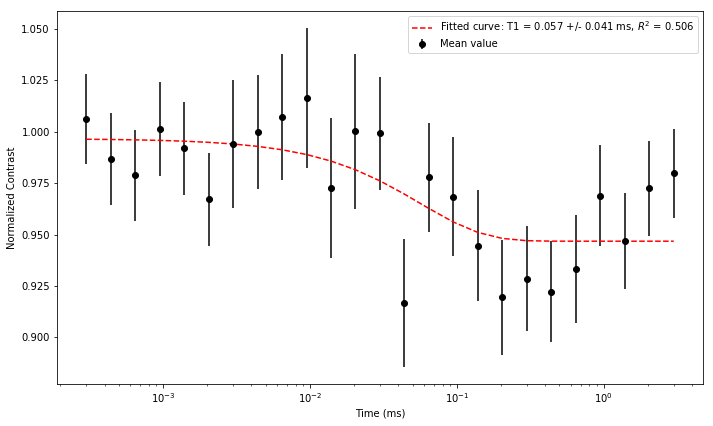

In [40]:
Y = np.mean(odmr_contrast, axis=0)
Y_std = np.mean(np.abs(odmr_contrast_err), axis=0)
analyze(Y, Y_std, t_axis)

## Dump the following

In [3]:
# Get the dictionary containing the default parameters for the desired sequence and alter the values as needed.
generate_params = pulsedmasterlogic.generate_method_params['t1_exponential_contrast']
generate_params['name'] = 'T1_single'
generate_params['tau_start'] =300e-09
generate_params['tau_end'] =400e-09
generate_params['num_of_points'] = 1
generate_params['alternating'] = False

# Call the actual generation method using a wrapper method and pass the parameter set
pulsedmasterlogic.generate_predefined_sequence('t1_exponential_contrast', generate_params)
# Give it a moment to generate
time.sleep(0.5)

In [4]:
# The created object is a PulseBlockEnsemble instance, a recipe to create a waveform.
# You can get all created PulseBlockEnsembles using this property (keys are ensemble names, values are the object instances):
for ensemble_name in pulsedmasterlogic.saved_pulse_block_ensembles.keys():
    print(ensemble_name)

T1
T1_contrast_based
T1_exp
T1_exp_contrastbased
T1_single
Testing_test
laser
pulsedODMR


In [5]:
# The "with_load" flag can be used to also load the waveform into the channels after creating it

pulsedmasterlogic.sample_ensemble('T1_single', with_load=True)

# Wait for the sampling to finish. There is a status dictionary that can be used to check for process status.

while pulsedmasterlogic.status_dict['sampload_busy']:
    time.sleep(0.1)

In [6]:
# You can check on the currently loaded asset on the pulse generator by using the following property:
print('currently loaded asset:', pulsedmasterlogic.loaded_asset)

# You can check on all created waveforms on the pulse generator by using the following property:
print('Available waveforms on device:', pulsedmasterlogic.sampled_waveforms)

currently loaded asset: ('T1', 'PulseBlockEnsemble')
Available waveforms on device: ['T1_single']


In [7]:
# If the pulse sequence has been generated not using predefined methods (e.g. using the graphical table editor) the 
# measurement settings have to be given manually.
# In the same way as setting the generation parameters you can either pass a settings dictionary or single keyword 
# arguments or a combination of both:
pulsedmasterlogic.set_measurement_settings(invoke_settings=False, 
                                           controlled_variable=[0],
                                           number_of_lasers=1, 
                                           laser_ignore_list=[], 
                                           alternating=False, 
                                           units=('s', 'arb. u.'))
time.sleep(0.5)

In [ ]:
# If everything is properly set, we can start a measurement simply by calling:
pulsedmasterlogic.toggle_pulsed_measurement(True)
# Wait until the pulsedmeasurementlogic is actually busy and the measurement is running
while pulsedmeasurementlogic.module_state() != 'locked':
    time.sleep(0.2)
contrast = pulsedmeasurementlogic.signal_data[1]
error = pulsedmeasurementlogic.measurement_error[1]

##  This will stop poi manager when measurement stops :))

In [21]:
# If everything is properly set, we can start a measurement simply by calling:
pulsedmasterlogic.toggle_pulsed_measurement(True)
# Wait until the pulsedmeasurementlogic is actually busy and the measurement is running
while pulsedmeasurementlogic.module_state() != 'locked':
    time.sleep(0.2)

In [22]:
pulsedmasterlogic.toggle_pulsed_measurement(False)
# Wait until the pulsedmeasurementlogic is actually idle and the measurement is stopped
while pulsedmeasurementlogic.module_state() == 'locked':
    #print(pulsedmeasurementlogic.module_state())
    time.sleep(0.2)

print("Final state:", pulsedmeasurementlogic.module_state())
poimanagerlogic.stop_periodic_refocus()

locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
locked
Final state: idle


In [3]:
print(pulsedmeasurementlogic.__elapsed_sweeps)

Traceback (most recent call last):
  File "C:\Users\SingleNV\qudi_old\logic\jupyterkernel\qzmqkernel.py", line 679, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-3-d161cf1f60c9>", line 1, in <module>
    print(pulsedmeasurementlogic.__elapsed_sweeps)
AttributeError: 'PulsedMeasurementLogic' object has no attribute '__elapsed_sweeps'


In [6]:
# You can get a read-only view of the current measurement settings by using this property:
for setting, value in pulsedmasterlogic.measurement_settings.items():
    print('{0}:\n  {1}'.format(setting, value))

invoke_settings:
  False
controlled_variable:
  [3.00000000e-07 4.40339780e-07 6.46330407e-07 9.48683298e-07
 1.39247665e-06 2.04387621e-06 3.00000000e-06 4.40339780e-06
 6.46330407e-06 9.48683298e-06 1.39247665e-05 2.04387621e-05
 3.00000000e-05 4.40339780e-05 6.46330407e-05 9.48683298e-05
 1.39247665e-04 2.04387621e-04 3.00000000e-04 4.40339780e-04
 6.46330407e-04 9.48683298e-04 1.39247665e-03 2.04387621e-03
 3.00000000e-03]
number_of_lasers:
  25
laser_ignore_list:
  []
alternating:
  False
units:
  ('s', 'arb. u.')
labels:
  ['Tau', 'Signal']


pulser on

In [1]:
pulsedmasterlogic.toggle_pulse_generator(False)

In [2]:
pulsedmasterlogic.toggle_pulse_generator(True)

In [1]:
print("hi")

hi


In [4]:
import types
import time

def count_odmr_new(self, length=100):
        """Switching off the fast counter"""
        print("Hello I'm from Jupyter")
    
        odmr = np.zeros((1, length))
        odmr_err = np.zeros((1, length))
        # self.trigger()
        for i in range(length):

            t1 = time.time()
            self.trigger()
            t2 = time.time()

            ############################################################
            # If everything is properly set, we can start a measurement simply by calling:
            self._pulsedmasterlogic.toggle_pulsed_measurement(True)
            print("initial state:", self._pulsedmasterlogic.module_state(), ", init sweep:",
                  self._pulsedmasterlogic.elapsed_sweeps)

            # time.sleep(5)
            while self._pulsedmasterlogic.status_dict['measurement_running'] == 0: #module_state() == 'locked':#
            # print(pulsedmeasurementlogic.module_state())
                time.sleep(0.2)
            self._poimanagerlogic.start_periodic_refocus()
            while self._pulsedmasterlogic.elapsed_sweeps != 1:
                time.sleep(0.2)

            while self._pulsedmasterlogic.elapsed_sweeps < 1:
                time.sleep(0.2)
            print("2")

            # we can stop measurement simply by calling:
            self._pulsedmasterlogic.toggle_pulsed_measurement(False)
            # Wait until the pulsedmeasurementlogic is actually idle and the measurement is stopped
            while self._pulsedmasterlogic.status_dict['measurement_running'] == 1:  # module_state() == 'locked':#
                # print(pulsedmeasurementlogic.module_state())
                time.sleep(0.2)
            print("Final state:", self._pulsedmasterlogic.module_state(), ", final sweep:",
                  self._pulsedmasterlogic.elapsed_sweeps)
            self._poimanagerlogic.stop_periodic_refocus()
            ############################################################

            contrast = self._pulsedmasterlogic.signal_data[1]
            error = self._pulsedmasterlogic.measurement_error[1]
            odmr[:, i] = contrast[0]
            odmr_err[:, i] = error[0]

            print("odmr:", odmr, odmr_err)

        self.trigger()
        return False, odmr

odmr_counter_microwave_interfuse.count_odmr = types.MethodType(
    count_odmr_new,
    odmr_counter_microwave_interfuse
)

In [4]:
import types
import time

def count_odmr_new(self, length=100):
        odmr = np.zeros((1, length))
        odmr_err = np.zeros((1, length))
        # self.trigger()
        for i in range(length):

            t1 = time.time()
            self.trigger()
            t2 = time.time()

            self._pulsedmasterlogic.toggle_pulse_generator(True)
            self._poimanagerlogic.start_periodic_refocus()
            time.sleep(7.5)
            self._poimanagerlogic.stop_periodic_refocus()
            self._pulsedmasterlogic.toggle_pulse_generator(False)
            ############################################################
            # If everything is properly set, we can start a measurement simply by calling:
            self._pulsedmasterlogic.toggle_pulsed_measurement(True)
            print("initial state:", self._pulsedmasterlogic.module_state(), ", init sweep:", self._pulsedmasterlogic.elapsed_sweeps)

            # time.sleep(5)
            while self._pulsedmasterlogic.status_dict['measurement_running'] == 0: #module_state() == 'locked':#
            # print(pulsedmeasurementlogic.module_state())
                time.sleep(0.2)

            while self._pulsedmasterlogic.elapsed_sweeps != 1:
                time.sleep(0.2)

            while self._pulsedmasterlogic.elapsed_sweeps < 2:
                time.sleep(0.2)
            print("2")

            # we can stop measurement simply by calling:
            self._pulsedmasterlogic.toggle_pulsed_measurement(False)
            # Wait until the pulsedmeasurementlogic is actually idle and the measurement is stopped
            while self._pulsedmasterlogic.status_dict['measurement_running'] == 1:  # module_state() == 'locked':#
                # print(pulsedmeasurementlogic.module_state())
                time.sleep(0.2)
            print("Final state:", self._pulsedmasterlogic.module_state(), ", final sweep:", self._pulsedmasterlogic.elapsed_sweeps)

            ############################################################

            contrast = self._pulsedmasterlogic.signal_data[1]
            error = self._pulsedmasterlogic.measurement_error[1]
            odmr[:, i] = contrast[0]
            odmr_err[:, i] = error[0]

            print("odmr:", odmr, odmr_err)

        self.trigger()
        return False, odmr
    
odmr_counter_microwave_interfuse.count_odmr = types.MethodType(
    count_odmr_new,
    odmr_counter_microwave_interfuse
)

In [3]:
print("gbg")

gbg
